# **<center>08_eval_exp06_external_institution_generalization</center>**

### Table of Contents

1. **Notebook Overview**
   - Objective of Experiment   
   - Dataset description (Institution 2)  
   - External validation rationale  

2. **Environment Setup**
   - Import of required libraries  

3. **Load External Test Data**
   - Load image paths  
   - Load metadata (CSV)  
   - Build dictionaries for subsets  

4. **Load Best CNN and Hydrid Model**
   - Model loading  
   - Summary of model architecture  

5. **Model Evaluation on External Subsets**
   - ROC curves  
   - Confusion matrices  
   - Threshold selection (Youden index)  
   - Full metrics: Sensitivity, Specificity, PPV, NPV, F1, Accuracy  
   - AUC confidence intervals (90–95–99%)

6. **Model Explainability**
   - Heatmap generation  
   - Representative examples (TP, TN, FP, FN)  
   - Heatmaps per subset  

7. **Summary and Conclusions**


### **1. Notebook Overview**

**Objective**

In this experiment we evaluate the external generalization ability of both the best convolutional neural network (CNN) and the corresponding hybrid CNN–ML model obtained in Experiment 1. Both models were developed using radiographs from Institution 1 only and are tested here on an independent external dataset from Institution 2. The objective is to assess whether image-based and feature-based approaches trained in a single center can preserve clinically useful performance when exposed to different patient populations, acquisition devices, and imaging protocols.

**Dataset (Institution 2)**

The external test set consists of 308 anonymized shoulder radiographs acquired at Institution 2 and grouped into three subsets according to the acquisition system:

- **TC_CZC2391BGR_test**: 126 images  
- **TC_CZC2161RCP_test**: 116 images  
- **TC_PRIMO_test**: 66 images (different manufacturer)

Each image is labeled for the presence or absence of rotator cuff tendon calcifications, following the same binary definition used in the internal experiments. No patient-identifying information is stored or used in this notebook. For the hybrid model, deep features extracted by the CNN were combined with the corresponding metadata to form the external feature set. No patient-identifying information is stored or used in this notebook.

**External validation rationale**

This experiment simulates a realistic deployment scenario in which models trained at a single institution are applied to data from an independent center with different equipment and acquisition conditions. By evaluating both the end-to-end CNN and the hybrid CNN–ML model on the combined external cohort and per acquisition system, we assess robustness to clinical and technical distribution shift and explore the feasibility of deploying both approaches beyond the development site.


### **2. Environment Setup**

In [3]:
# System and utilities
import os
from datetime import datetime
import math
from ast import literal_eval

# Numerical computing and data structures
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import norm
from scipy.stats import chi2

# Visualization 
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Image

# Deep Learning 
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Conv2D, SeparableConv2D, DepthwiseConv2D

# Machine Learning and metrics
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score
)
from sklearn.inspection import permutation_importance

import joblib

# Image processing
import cv2

# Others
from tqdm.auto import tqdm 
import shap

2026-02-12 21:47:29.783189: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-12 21:47:30.652348: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


### **3. Load External Test Data**

#### **3.1. Load images**

In [2]:
# Base path for the EXTERNAL test subsets (cropped images for CNN evaluation)
subsets_path = 'Dataset/External_text_Institution_2'

# Dictionary with external test subsets (stations)
external_subsets = {
    'TC_CZC2391BGR_test': [],
    'TC_CZC2161RCP_test': [],
    'TC_PRIMO_test': []
}

# Populate each subset list with the full paths of the images
for subset_name in external_subsets.keys():
    subset_path = os.path.join(subsets_path, subset_name)

    image_paths = [
        os.path.join(subset_path, img_name)
        for img_name in os.listdir(subset_path)
        if img_name.endswith('.npy')
    ]

    external_subsets[subset_name] = image_paths
    print(f'Images in {subset_name}: {len(image_paths)}')


ml_test_features_path = (
    'Dataset/External_text_Institution_2'
    'EXP_ML_external_test_features.csv'
)

# Path to the trained Machine Learning model (trained on internal data)
modelo_path = 'Dataset/Machine_Learning/mejor_modelo.pkl'


Images in TC_CZC2391BGR_test: 126
Images in TC_CZC2161RCP_test: 116
Images in TC_PRIMO_test: 66


In [3]:
# Helper function to load images

def load_images(images_path):
    """
    Load a list of .npy images into a single NumPy array.
    
    Parameters
    ----------
    images_path : list of str
        List of file paths to .npy images.
    
    Returns
    -------
    np.ndarray
        Stacked NumPy array of images if possible.
        If no images are provided, returns an empty array with shape (0,).
    """
    if len(images_path) == 0:
        print('No image paths provided. Returning empty array.')
        return np.empty((0,))

    X_list = []
    shapes_detected = set()

    for image_path in tqdm(images_path, desc='Loading images'):
        try:
            X_ = np.load(image_path)
            shapes_detected.add(X_.shape)
            X_list.append(X_)
        except Exception as e:
            print(f'Warning: error loading {image_path}: {e}')

    if len(shapes_detected) == 0:
        print('No images were successfully loaded. Returning empty array.')
        return np.empty((0,))

    if len(shapes_detected) > 1:
        print(f'Warning: multiple image shapes detected: {shapes_detected}')
    else:
        print(f'All images share the same shape: {list(shapes_detected)[0]}')

    try:
        # np.stack is safer than np.array in this context
        X = np.stack(X_list)
    except Exception as e:
        print(f'Error converting list to NumPy array: {e}')
        X = np.empty((0,))

    return X


#### **3.2. Load metadata**

In [4]:
# Helper function to extract labels from metadata

def extract_labels(df, images_path):
    """
    Extract labels for each image based on its file name and a metadata DataFrame.
    
    The DataFrame is expected to contain:
      - 'rx_cod': image identifier (matching the file name without extension)
      - 'label_CalTend': corresponding label for calcific tendinopathy
    
    Parameters
    ----------
    df : pandas.DataFrame
        Metadata DataFrame with at least 'rx_cod' and 'label_CalTend' columns.
    images_path : list of str
        List of image file paths (.npy).
    
    Returns
    -------
    np.ndarray
        Array of labels aligned with the order of images_path.
    """
    # Build a dict: rx_cod -> label
    label_dict = dict(zip(df['rx_cod'], df['label_CalTend']))
    
    # Extract labels based on the file name (without extension)
    y = np.array([
        label_dict[os.path.splitext(os.path.basename(path))[0]]
        for path in images_path
    ])
    
    return y


In [5]:
# Dictionary to store the loaded arrays
X_external_dict = {}

for subset_name, image_paths in external_subsets.items():
    print(f'\n🔍 Loading images from subset: {subset_name}')
    X_external_dict[subset_name] = load_images(image_paths)
    print(f'✅ Loaded {X_external_dict[subset_name].shape[0]} images from {subset_name}')



🔍 Loading images from subset: TC_CZC2391BGR_test


Loading images: 100%|█████████████████████████| 126/126 [00:03<00:00, 40.11it/s]


All images share the same shape: (512, 512, 3)
✅ Loaded 126 images from TC_CZC2391BGR_test

🔍 Loading images from subset: TC_CZC2161RCP_test


Loading images: 100%|█████████████████████████| 116/116 [00:03<00:00, 29.90it/s]


All images share the same shape: (512, 512, 3)
✅ Loaded 116 images from TC_CZC2161RCP_test

🔍 Loading images from subset: TC_PRIMO_test


Loading images: 100%|███████████████████████████| 66/66 [00:01<00:00, 43.71it/s]


All images share the same shape: (512, 512, 3)
✅ Loaded 66 images from TC_PRIMO_test


In [6]:
# Dictionary to store the DataFrames containing metadata for each subset
df_external_dict = {}

# Load CSV files associated with each external test subset
for subset_name in external_subsets.keys():
    csv_path = os.path.join(subsets_path, subset_name + '.csv')
    df = pd.read_csv(csv_path)
    df_external_dict[subset_name] = df
    print(f'📄 Rows in {subset_name}: {df.shape[0]}')

# Merge all arrays from the external subsets into a single array
X_all = np.concatenate(list(X_external_dict.values()), axis=0)
print(f'✅ All images concatenated: {X_all.shape}')


📄 Rows in TC_CZC2391BGR_test: 126
📄 Rows in TC_CZC2161RCP_test: 116
📄 Rows in TC_PRIMO_test: 66
✅ All images concatenated: (308, 512, 512, 3)


#### **3.3. Build dictionaries for subsets** 

In [7]:
# Dictionary to store the labels for each external subset
y_external_dict = {}

# Extract labels for each subset
for subset_name in external_subsets.keys():
    print(f'🏷️ Extracting labels for {subset_name}')
    
    image_paths = external_subsets[subset_name]
    df = df_external_dict[subset_name]
    
    # Get the labels using the metadata DataFrame and image paths
    y = extract_labels(df, image_paths)
    y_external_dict[subset_name] = y
    
    print(f'✅ Labels extracted: {len(y)}')


🏷️ Extracting labels for TC_CZC2391BGR_test
✅ Labels extracted: 126
🏷️ Extracting labels for TC_CZC2161RCP_test
✅ Labels extracted: 116
🏷️ Extracting labels for TC_PRIMO_test
✅ Labels extracted: 66


In [8]:
# Merge all image arrays into a single NumPy array
X_all = np.concatenate([X_external_dict[name] for name in external_subsets.keys()], axis=0)
print(f'✅ Total images: {X_all.shape}')

# Merge all label arrays into a single NumPy array
y_all = np.concatenate([y_external_dict[name] for name in external_subsets.keys()], axis=0)
print(f'✅ Total labels: {y_all.shape}')

# Merge all metadata DataFrames into a single DataFrame
df_all = pd.concat([df_external_dict[name] for name in external_subsets.keys()], axis=0).reset_index(drop=True)
print(f'📄 Total rows in df_all: {df_all.shape}')

# Final consistency check
assert X_all.shape[0] == y_all.shape[0] == df_all.shape[0], \
    "Mismatch between images, labels, or metadata"


✅ Total images: (308, 512, 512, 3)
✅ Total labels: (308,)
📄 Total rows in df_all: (308, 16)


In [9]:
# Load EXTERNAL test features for the Hybrid CNN + ML model

ml_test_features_path = (
    'Dataset/External_text_Institution_2/Subsets_no_unet/'
    'EXP_ML_external_test_features.csv'
)

df_ml_external = pd.read_csv(ml_test_features_path, index_col=0)

print('External ML feature table loaded')
print('Shape:', df_ml_external.shape)
print('Label distribution:')
print(df_ml_external['label'].value_counts())


External ML feature table loaded
Shape: (308, 518)
Label distribution:
label
0    154
1    154
Name: count, dtype: int64


### **4. Load Best CNN and CNN-ML Model**

In [10]:
# Path to the best CNN model
model_path = (
    'best_cnn_model.h5'
)

# Load the trained model
model = load_model(model_path)

# Path to the Machine Learning model (.pkl)
modelo_path = 'Dataset/Machine_Learning/mejor_modelo.pkl'

# Load the trained SVM model
svm_model = joblib.load(modelo_path)
print('\nEXPERIMENT — SVM model loaded from:', modelo_path)

# Display model summary
print('EXPERIMENT — Best CNN model:')
model.summary()


2026-02-06 15:42:50.728246: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-02-06 15:42:50.795769: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-02-06 15:42:50.798893: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf


EXPERIMENT — SVM model loaded from: Dataset/Machine_Learning/mejor_modelo.pkl
EXPERIMENT — Best CNN model:
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg19 (Functional)          (None, 16, 16, 512)       20024384  
                                                                 
 global_max_pooling2d (Glob  (None, 512)               0         
 alMaxPooling2D)                                                 
                                                                 
 dense (Dense)               (None, 1)                 513       
                                                                 
Total params: 20024897 (76.39 MB)
Trainable params: 20024897 (76.39 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### **5. Model Evaluation on External Subsets**

In [11]:
# Prepare EXTERNAL test data for the Hybrid ML model

# Load the EXTERNAL test feature set
df_test = pd.read_csv(ml_test_features_path, index_col=0)
print('Raw EXTERNAL ML test features loaded:')
display(df_test.head(0))

# Ensure age is available (compute if needed)
if 'age' not in df_test.columns:
    df_test = calcular_edad(df_test)

print('\nEXTERNAL ML test features with age column:')
display(df_test.head(0))

# Work on a copy to preserve the original DataFrame
df_test_ml = df_test.copy()

# Drop non-feature columns if present
columns_to_drop = ['birthdate']
for col in columns_to_drop:
    if col in df_test_ml.columns:
        df_test_ml.drop(columns=[col], inplace=True)

# Separate features (X) and label (y)
X_test = df_test_ml.drop(columns=['label'])
y_test = df_test_ml['label']

# Encode sex as numeric (F -> 0, M -> 1)
if 'sex' in X_test.columns:
    X_test['sex'] = X_test['sex'].map({'F': 0, 'M': 1})
    if X_test['sex'].isnull().any():
        X_test['sex'].fillna(X_test['sex'].mode()[0], inplace=True)

print('\nEXTERNAL ML test set prepared.')
print('X_test shape:', X_test.shape)
print('y_test shape:', y_test.shape)


Raw EXTERNAL ML test features loaded:


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_509,feature_510,feature_511,feature_512,label,sex,birthdate,date_rx,station_name,age



EXTERNAL ML test features with age column:


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_509,feature_510,feature_511,feature_512,label,sex,birthdate,date_rx,station_name,age



EXTERNAL ML test set prepared.
X_test shape: (308, 516)
y_test shape: (308,)


In [14]:
# AUC confidence interval helpers

def auc_confidence_interval_analytic(y_true, y_score, alpha_values=(0.90, 0.95, 0.99)):
    """
    Compute approximate confidence intervals for ROC AUC using 
    an analytic method (Hanley & McNeil style approximation).
    
    Parameters
    ----------
    y_true : array-like
        True binary labels.
    y_score : array-like
        Predicted scores or probabilities.
    alpha_values : tuple of float, optional
        Confidence levels to compute (e.g., (0.90, 0.95, 0.99)).
    
    Returns
    -------
    auc : float
        Area under the ROC curve.
    ci_dict : dict
        Dictionary with keys like 'CI 90% lower', 'CI 90% upper', etc.
    """
    auc = roc_auc_score(y_true, y_score)
    n1 = sum(y_true)
    n2 = len(y_true) - n1
    q1 = auc / (2 - auc)
    q2 = 2 * auc**2 / (1 + auc)
    se_auc = np.sqrt(
        (auc * (1 - auc) +
         (n1 - 1) * (q1 - auc**2) +
         (n2 - 1) * (q2 - auc**2)) / (n1 * n2)
    )

    # Common z-scores
    z_table = {0.90: 1.6449, 0.95: 1.96, 0.99: 2.5758}
    ci_dict = {}

    for level in alpha_values:
        z = z_table[level]
        delta = z * se_auc
        ci_dict[f'CI {int(level * 100)}% lower'] = max(0, auc - delta)
        ci_dict[f'CI {int(level * 100)}% upper'] = min(1, auc + delta)

    return auc, ci_dict


def auc_confidence_interval_bootstrap(y_true, y_score, n_bootstraps=1000, seed=42):
    """
    Compute bootstrap confidence intervals for ROC AUC.
    
    Parameters
    ----------
    y_true : array-like
        True binary labels.
    y_score : array-like
        Predicted scores or probabilities.
    n_bootstraps : int, optional
        Number of bootstrap samples.
    seed : int, optional
        Random seed for reproducibility.
    
    Returns
    -------
    auc : float
        Area under the ROC curve.
    ci_dict : dict
        Dictionary with keys for 90%, 95% and 99% confidence intervals.
    """
    rng = np.random.RandomState(seed)
    bootstrapped_scores = []

    y_true = np.array(y_true)
    y_score = np.array(y_score)

    for _ in range(n_bootstraps):
        indices = rng.randint(0, len(y_score), len(y_score))
        # Need at least one positive and one negative sample in each bootstrap
        if len(np.unique(y_true[indices])) < 2:
            continue
        score = roc_auc_score(y_true[indices], y_score[indices])
        bootstrapped_scores.append(score)

    sorted_scores = np.sort(bootstrapped_scores)

    ci_90 = (
        sorted_scores[int(0.05 * len(sorted_scores))],
        sorted_scores[int(0.95 * len(sorted_scores))]
    )
    ci_95 = (
        sorted_scores[int(0.025 * len(sorted_scores))],
        sorted_scores[int(0.975 * len(sorted_scores))]
    )
    ci_99 = (
        sorted_scores[int(0.005 * len(sorted_scores))],
        sorted_scores[int(0.995 * len(sorted_scores))]
    )

    auc = roc_auc_score(y_true, y_score)
    ci_dict = {
        'CI 90% lower': ci_90[0], 'CI 90% upper': ci_90[1],
        'CI 95% lower': ci_95[0], 'CI 95% upper': ci_95[1],
        'CI 99% lower': ci_99[0], 'CI 99% upper': ci_99[1],
    }

    return auc, ci_dict


# --- AUC Confidence Interval Helpers ---

def auc_confidence_interval_analytic(y_true, y_score, alpha_values=(0.90, 0.95, 0.99)):
    """
    Compute approximate confidence intervals for ROC AUC using 
    an analytic method (Hanley & McNeil style approximation).
    """
    auc = roc_auc_score(y_true, y_score)
    n1 = sum(y_true)
    n2 = len(y_true) - n1
    q1 = auc / (2 - auc)
    q2 = 2 * auc**2 / (1 + auc)
    se_auc = np.sqrt(
        (auc * (1 - auc) +
         (n1 - 1) * (q1 - auc**2) +
         (n2 - 1) * (q2 - auc**2)) / (n1 * n2)
    )

    # Common z-scores
    z_table = {0.90: 1.6449, 0.95: 1.96, 0.99: 2.5758}
    ci_dict = {}

    for level in alpha_values:
        z = z_table[level]
        delta = z * se_auc
        ci_dict[f'CI {int(level * 100)}% lower'] = max(0, auc - delta)
        ci_dict[f'CI {int(level * 100)}% upper'] = min(1, auc + delta)

    return auc, ci_dict


def auc_confidence_interval_bootstrap(y_true, y_score, n_bootstraps=1000, seed=42):
    """
    Compute bootstrap confidence intervals for ROC AUC.
    """
    rng = np.random.RandomState(seed)
    bootstrapped_scores = []

    y_true = np.array(y_true)
    y_score = np.array(y_score)

    for _ in range(n_bootstraps):
        indices = rng.randint(0, len(y_score), len(y_score))
        if len(np.unique(y_true[indices])) < 2:
            continue
        score = roc_auc_score(y_true[indices], y_score[indices])
        bootstrapped_scores.append(score)

    sorted_scores = np.sort(bootstrapped_scores)

    ci_90 = (
        sorted_scores[int(0.05 * len(sorted_scores))],
        sorted_scores[int(0.95 * len(sorted_scores))]
    )
    ci_95 = (
        sorted_scores[int(0.025 * len(sorted_scores))],
        sorted_scores[int(0.975 * len(sorted_scores))]
    )
    ci_99 = (
        sorted_scores[int(0.005 * len(sorted_scores))],
        sorted_scores[int(0.995 * len(sorted_scores))]
    )

    auc = roc_auc_score(y_true, y_score)
    ci_dict = {
        'CI 90% lower': ci_90[0], 'CI 90% upper': ci_90[1],
        'CI 95% lower': ci_95[0], 'CI 95% upper': ci_95[1],
        'CI 99% lower': ci_99[0], 'CI 99% upper': ci_99[1],
    }

    return auc, ci_dict

# --- Timing Helper Function ---

def measure_inference_time(model, X, model_type='cnn'):
    """
    Runs prediction on X using the model and measures the elapsed time.
    
    Parameters
    ----------
    model : object
        The trained model (CNN or SVM).
    X : array-like
        The input data for prediction.
    model_type : str, optional
        'cnn' or 'svm' to handle specific prediction calls.
        
    Returns
    -------
    y_pred_prob : array
        The predicted probabilities/scores.
    total_time : float
        Total time taken for inference in seconds.
    time_per_sample : float
        Time taken per single sample in seconds.
    """
    start_time = time.time()
    
    if model_type == 'cnn':
        # CNN prediction logic
        y_pred_prob = model.predict(X).ravel()
        
    elif model_type == 'svm':
        # SVM prediction logic
        if hasattr(model, "predict_proba"):
            y_pred_prob = model.predict_proba(X)[:, 1]
        elif hasattr(model, "decision_function"):
            y_scores = model.decision_function(X)
            # Scale decision scores to [0, 1]
            y_pred_prob = (y_scores - y_scores.min()) / (y_scores.max() - y_scores.min())
        else:
            raise ValueError("The model does not support predict_proba or decision_function.")
    else:
        # Default fallback
        y_pred_prob = model.predict(X)
        
    end_time = time.time()
    
    total_time = end_time - start_time
    time_per_sample = total_time / len(X)
    
    return y_pred_prob, total_time, time_per_sample

#### **5.1. CNN evaluation on External Test Subset**

2026-02-06 15:50:53.189977: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 968884224 exceeds 10% of free system memory.
2026-02-06 15:50:54.238272: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 968884224 exceeds 10% of free system memory.


10/10 [==============================] - 7s 752ms/step

=== Evaluation: External_DL_best_model (CNN – External) ===
Confusion matrix:
[[141 13]
 [22 132]]

Cut-off threshold: 0.4083
Sensitivity: 0.8571
Specificity: 0.9156
PPV: 0.9103
NPV: 0.8650
F1 score: 0.8829
Accuracy: 0.8864
ROC AUC: 0.9399
CI 90%: [0.9166 – 0.9631]
CI 95%: [0.9122 – 0.9676]
CI 99%: [0.9035 – 0.9763]
Total inference time: 10.9252 sec
Time per sample: 0.035471 sec



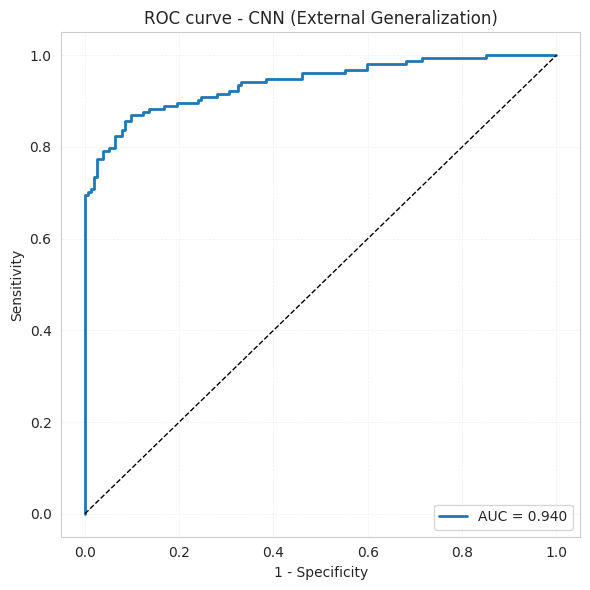

In [21]:
# CNN evaluation — EXTERNAL GENERALIZATION (with inference time)

# Output directory for CNN external evaluation
save_dir_cnn = 'Evaluation/EXP_external/DL'
os.makedirs(save_dir_cnn, exist_ok=True)

# Custom names
evaluation_name_cnn = 'External_DL_best_model'
plot_name_cnn = evaluation_name_cnn + '_ROC.png'
metrics_name_cnn = evaluation_name_cnn + '_metrics.csv'

# Test data for CNN (EXTERNAL)
X_test_cnn = X_all
y_true_cnn = y_all

# --- Predict with Timing ---
y_pred_prob_cnn, total_time_cnn, time_per_sample_cnn = measure_inference_time(
    model,
    X_test_cnn,
    model_type='cnn'
)

# ROC curve
fpr_cnn, tpr_cnn, thresholds_cnn = roc_curve(y_true_cnn, y_pred_prob_cnn)

# Select threshold based on clinical criterion (sens ≥ 0.85 and spec ≥ 0.70)
best_idx_cnn = None
for i in range(len(thresholds_cnn)):
    sens = tpr_cnn[i]
    spec = 1 - fpr_cnn[i]
    if sens >= 0.85 and spec >= 0.70:
        best_idx_cnn = i
        break

if best_idx_cnn is None:
    print("No clinical threshold found. Using Youden Index.")
    best_idx_cnn = np.argmax(tpr_cnn - fpr_cnn)

best_threshold_cnn = thresholds_cnn[best_idx_cnn]
y_pred_cnn = (y_pred_prob_cnn >= best_threshold_cnn).astype(int)

# Metrics
tn, fp, fn, tp = confusion_matrix(y_true_cnn, y_pred_cnn).ravel()
sensitivity = recall_score(y_true_cnn, y_pred_cnn)
specificity = tn / (tn + fp) if (tn + fp) else 0
ppv = precision_score(y_true_cnn, y_pred_cnn)
npv = tn / (tn + fn) if (tn + fn) else 0
f1 = f1_score(y_true_cnn, y_pred_cnn)
acc = accuracy_score(y_true_cnn, y_pred_cnn)

# AUC and confidence intervals (analytic method)
auc_cnn, ci_dict_cnn = auc_confidence_interval_analytic(
    y_true_cnn, y_pred_prob_cnn
)

# Save metrics to CSV (including timing)
df_metrics_cnn = pd.DataFrame({
    'Evaluation_name': [evaluation_name_cnn],
    'cut_off_threshold_point': [round(best_threshold_cnn, 4)],
    'tn': [tn], 'fp': [fp], 'fn': [fn], 'tp': [tp],
    'sensitivity': [round(sensitivity, 4)],
    'specificity': [round(specificity, 4)],
    'PPV': [round(ppv, 4)],
    'NPV': [round(npv, 4)],
    'F1 score': [round(f1, 4)],
    'accuracy': [round(acc, 4)],
    'ROC AUC': [round(auc_cnn, 4)],
    'total_inference_time_sec': [round(total_time_cnn, 6)],
    'time_per_sample_sec': [round(time_per_sample_cnn, 6)],
    'CI 90% lower': [round(ci_dict_cnn['CI 90% lower'], 4)],
    'CI 90% upper': [round(ci_dict_cnn['CI 90% upper'], 4)],
    'CI 95% lower': [round(ci_dict_cnn['CI 95% lower'], 4)],
    'CI 95% upper': [round(ci_dict_cnn['CI 95% upper'], 4)],
    'CI 99% lower': [round(ci_dict_cnn['CI 99% lower'], 4)],
    'CI 99% upper': [round(ci_dict_cnn['CI 99% upper'], 4)],
    'y_true': [list(y_true_cnn)],
    'y_pred_prob': [list(y_pred_prob_cnn)]
})

df_metrics_cnn.to_csv(
    os.path.join(save_dir_cnn, metrics_name_cnn),
    index=False
)

# Print metrics
print(f"\n=== Evaluation: {evaluation_name_cnn} (CNN – External) ===")
print(f"Confusion matrix:\n[[{tn} {fp}]\n [{fn} {tp}]]\n")
print(f'Cut-off threshold: {best_threshold_cnn:.4f}')
print(f'Sensitivity: {sensitivity:.4f}')
print(f'Specificity: {specificity:.4f}')
print(f'PPV: {ppv:.4f}')
print(f'NPV: {npv:.4f}')
print(f'F1 score: {f1:.4f}')
print(f'Accuracy: {acc:.4f}')
print(f'ROC AUC: {auc_cnn:.4f}')
print(f"CI 90%: [{ci_dict_cnn['CI 90% lower']:.4f} – {ci_dict_cnn['CI 90% upper']:.4f}]")
print(f"CI 95%: [{ci_dict_cnn['CI 95% lower']:.4f} – {ci_dict_cnn['CI 95% upper']:.4f}]")
print(f"CI 99%: [{ci_dict_cnn['CI 99% lower']:.4f} – {ci_dict_cnn['CI 99% upper']:.4f}]")
print(f"Total inference time: {total_time_cnn:.4f} sec")
print(f"Time per sample: {time_per_sample_cnn:.6f} sec\n")

# ROC curve plot
sns.set_style("whitegrid")
plt.figure(figsize=(6, 6))
plt.plot(fpr_cnn, tpr_cnn, linewidth=2, label=f'AUC = {auc_cnn:.3f}')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.3)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)

plt.xlabel('1 - Specificity')
plt.ylabel('Sensitivity')
plt.title('ROC curve - CNN (External Generalization)')
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()

plt.savefig(
    os.path.join(save_dir_cnn, plot_name_cnn),
    bbox_inches='tight',
    dpi=300
)

plt.show()
plt.close()


#### **5.2. ML (SVM) evaluation on External Test Subset**


=== Evaluation: External_ML_SVM (SVM – External) ===
Confusion matrix:
[[144 10]
 [23 131]]

Cut-off threshold: 0.4760
Sensitivity: 0.8506
Specificity: 0.9351
PPV: 0.9291
NPV: 0.8623
F1 score: 0.8881
Accuracy: 0.8929
ROC AUC: 0.9406
CI 90%: [0.9174 – 0.9610]
CI 95%: [0.9136 – 0.9644]
CI 99%: [0.8950 – 0.9707]
Total inference time: 0.0164 sec
Time per sample: 0.000053 sec

Metrics for the external SVM model saved to:
Evaluation/EXP_external/ML/External_ML_SVM_metrics.csv


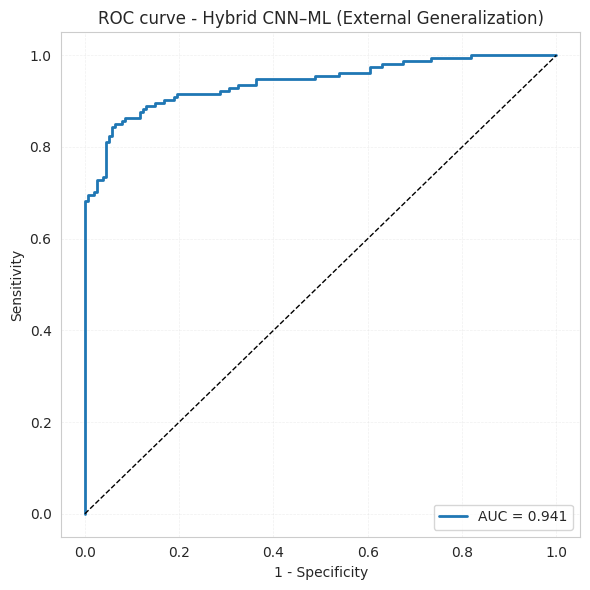


   COMPUTATIONAL EFFICIENCY COMPARISON
The ML (SVM) model is faster than the DL (CNN) model.
Time difference (total): 10.9088 seconds
Speedup factor: 667.76x
----------------------------------------
CNN time per sample: 0.035471 sec
SVM time per sample: 0.000053 sec


In [22]:
# ML evaluation (SVM) — EXTERNAL GENERALIZATION (with timing)

# Output directory for ML external evaluation
save_dir_ml = 'Evaluation/EXP_external/ML'
os.makedirs(save_dir_ml, exist_ok=True)

evaluation_name_ml = 'External_ML_SVM'

# --- Predict with Timing ---
y_pred_prob_ml, total_time_ml, time_per_sample_ml = measure_inference_time(
    svm_model,
    X_test,
    model_type='svm'
)

# ROC curve
fpr_ml, tpr_ml, thresholds_ml = roc_curve(y_test, y_pred_prob_ml)

# Select threshold based on clinical criterion (sens ≥ 0.85 and spec ≥ 0.70)
best_idx_ml = None
for i in range(len(thresholds_ml)):
    sens = tpr_ml[i]
    spec = 1 - fpr_ml[i]
    if sens >= 0.85 and spec >= 0.70:
        best_idx_ml = i
        break

if best_idx_ml is None:
    print("No clinical threshold found. Using Youden Index.")
    best_idx_ml = np.argmax(tpr_ml - fpr_ml)

best_threshold_ml = thresholds_ml[best_idx_ml]
y_pred_ml = (y_pred_prob_ml >= best_threshold_ml).astype(int)

# Metrics
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_ml).ravel()
sensitivity_ml = recall_score(y_test, y_pred_ml)
specificity_ml = tn / (tn + fp) if (tn + fp) else 0
ppv_ml = precision_score(y_test, y_pred_ml)
npv_ml = tn / (tn + fn) if (tn + fn) else 0
f1_ml = f1_score(y_test, y_pred_ml)
acc_ml = accuracy_score(y_test, y_pred_ml)

# AUC and confidence intervals (bootstrap method)
auc_ml, ci_dict_ml = auc_confidence_interval_bootstrap(
    y_test, y_pred_prob_ml
)

# Print metrics
print(f'\n=== Evaluation: {evaluation_name_ml} (SVM – External) ===')
print(f'Confusion matrix:\n[[{tn} {fp}]\n [{fn} {tp}]]\n')
print(f'Cut-off threshold: {best_threshold_ml:.4f}')
print(f'Sensitivity: {sensitivity_ml:.4f}')
print(f'Specificity: {specificity_ml:.4f}')
print(f'PPV: {ppv_ml:.4f}')
print(f'NPV: {npv_ml:.4f}')
print(f'F1 score: {f1_ml:.4f}')
print(f'Accuracy: {acc_ml:.4f}')
print(f'ROC AUC: {auc_ml:.4f}')
print(f"CI 90%: [{ci_dict_ml['CI 90% lower']:.4f} – {ci_dict_ml['CI 90% upper']:.4f}]")
print(f"CI 95%: [{ci_dict_ml['CI 95% lower']:.4f} – {ci_dict_ml['CI 95% upper']:.4f}]")
print(f"CI 99%: [{ci_dict_ml['CI 99% lower']:.4f} – {ci_dict_ml['CI 99% upper']:.4f}]")
print(f"Total inference time: {total_time_ml:.4f} sec")
print(f"Time per sample: {time_per_sample_ml:.6f} sec")

# Save metrics to CSV (including timing)
df_metrics_ml = pd.DataFrame({
    'Evaluation_name': [evaluation_name_ml],
    'cut_off_threshold_point': [round(best_threshold_ml, 4)],
    'tn': [tn], 'fp': [fp], 'fn': [fn], 'tp': [tp],
    'sensitivity': [round(sensitivity_ml, 4)],
    'specificity': [round(specificity_ml, 4)],
    'PPV': [round(ppv_ml, 4)],
    'NPV': [round(npv_ml, 4)],
    'F1 score': [round(f1_ml, 4)],
    'accuracy': [round(acc_ml, 4)],
    'ROC AUC': [round(auc_ml, 4)],
    'total_inference_time_sec': [round(total_time_ml, 6)],
    'time_per_sample_sec': [round(time_per_sample_ml, 6)],
    'CI 90% lower': [round(ci_dict_ml['CI 90% lower'], 4)],
    'CI 90% upper': [round(ci_dict_ml['CI 90% upper'], 4)],
    'CI 95% lower': [round(ci_dict_ml['CI 95% lower'], 4)],
    'CI 95% upper': [round(ci_dict_ml['CI 95% upper'], 4)],
    'CI 99% lower': [round(ci_dict_ml['CI 99% lower'], 4)],
    'CI 99% upper': [round(ci_dict_ml['CI 99% upper'], 4)],
    'y_true': [list(y_test)],
    'y_pred_prob': [list(y_pred_prob_ml)]
})

csv_path_ml = os.path.join(
    save_dir_ml,
    evaluation_name_ml + '_metrics.csv'
)

df_metrics_ml.to_csv(csv_path_ml, index=False)
print(f"\nMetrics for the external SVM model saved to:\n{csv_path_ml}")

# ROC curve plot
plt.figure(figsize=(6, 6))
plt.plot(fpr_ml, tpr_ml, linewidth=2, label=f'AUC = {auc_ml:.3f}')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.3)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)

plt.xlabel('1 - Specificity')
plt.ylabel('Sensitivity')
plt.title('ROC curve - Hybrid CNN–ML (External Generalization)')
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()

plt.savefig(
    os.path.join(save_dir_ml, evaluation_name_ml + '_ROC.png'),
    bbox_inches='tight',
    dpi=300
)

plt.show()
plt.close()

# EFFICIENCY COMPARISON — CNN vs ML (External)

print("\n" + "=" * 40)
print("   COMPUTATIONAL EFFICIENCY COMPARISON")
print("=" * 40)

if 'total_time_cnn' in locals() and 'total_time_ml' in locals():

    diff_time = abs(total_time_cnn - total_time_ml)

    if total_time_ml < total_time_cnn:
        speedup = total_time_cnn / total_time_ml if total_time_ml > 0 else 0
        faster_model = "ML (SVM)"
        slower_model = "DL (CNN)"
    else:
        speedup = total_time_ml / total_time_cnn if total_time_cnn > 0 else 0
        faster_model = "DL (CNN)"
        slower_model = "ML (SVM)"

    print(f"The {faster_model} model is faster than the {slower_model} model.")
    print(f"Time difference (total): {diff_time:.4f} seconds")
    print(f"Speedup factor: {speedup:.2f}x")
    print("-" * 40)
    print(f"CNN time per sample: {time_per_sample_cnn:.6f} sec")
    print(f"SVM time per sample: {time_per_sample_ml:.6f} sec")
    print("=" * 40)

else:
    print("Could not compare models (timing variables missing).")


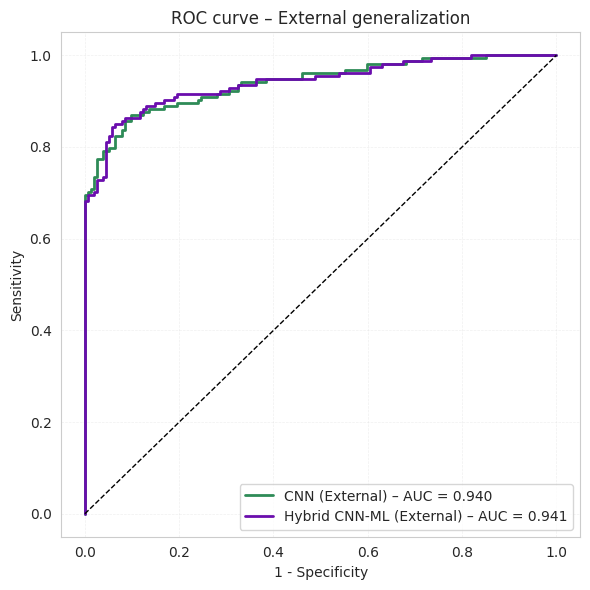

External ROC curve saved to:
Evaluation/EXP_EXT/ExpExt_DL_ML_ROC.png


In [43]:
# Combined ROC curve – EXTERNAL generalization (CNN vs Hybrid)

# ROC curves and AUC already computed above:
# fpr_dl, tpr_dl, auc_dl
# fpr_ml, tpr_ml, auc_ml

sns.set_style("whitegrid")
plt.figure(figsize=(6, 6))

# CNN external – green
plt.plot(
    fpr_dl, tpr_dl,
    color='#2E8B57', linewidth=2,
    label=f'CNN (External) – AUC = {auc_dl:.3f}'
)

# Hybrid CNN-ML external – purple
plt.plot(
    fpr_ml, tpr_ml,
    color='#6A0DAD', linewidth=2,
    label=f'Hybrid CNN-ML (External) – AUC = {auc_ml:.3f}'
)

# Reference diagonal
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.3)
plt.xlabel('1 - Specificity')
plt.ylabel('Sensitivity')
plt.title('ROC curve – External generalization')

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)

plt.legend(loc='lower right', frameon=True)
plt.tight_layout()

plot_path = 'Evaluation/EXP_EXT/ExpExt_DL_ML_ROC.png'
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print(f"External ROC curve saved to:\n{plot_path}")


#### **5.3. Statistical comparison between CNN and SVM models (DeLong for AUC)**

In [42]:
# CNN predictions aligned by rx_cod (EXTERNAL)

rx_cod_ml = df_test_ml.index.values.copy()

ID_COL = 'rx_cod'

ids_all = []
y_all_rebuilt = []

for subset_name in external_subsets.keys():
    image_paths = external_subsets[subset_name]
    ids_subset = [os.path.splitext(os.path.basename(p))[0] for p in image_paths]
    ids_all.extend(ids_subset)
    y_all_rebuilt.extend(list(y_external_dict[subset_name]))

ids_all = np.array(ids_all)
y_all_rebuilt = np.array(y_all_rebuilt)

# Sanity check
assert np.array_equal(y_all_rebuilt, y_true_cnn), \
    "CNN label order mismatch — check subset concatenation."

df_cnn_eval = pd.DataFrame({
    ID_COL: ids_all,
    'label': y_true_cnn,
    'y_pred_prob_cnn': y_pred_prob_cnn
}).set_index(ID_COL)

print(f"CNN external cases: {df_cnn_eval.shape[0]}")

# ML predictions aligned by rx_cod (EXTERNAL)

# rx_cod order used for ML prediction
rx_cod_ml = df_test_ml.index.values.copy()

df_ml_eval = pd.DataFrame({
    ID_COL: rx_cod_ml,
    'label': y_test.values,
    'y_pred_prob_ml': y_pred_prob_ml
}).set_index(ID_COL)

print(f"ML external cases: {df_ml_eval.shape[0]}")

CNN external cases: 308
ML external cases: 308


In [40]:
# Align CNN and ML predictions (INNER JOIN)

df_joint = df_cnn_eval.join(df_ml_eval, how='inner', lsuffix='_cnn', rsuffix='_ml')

print(f"Common cases CNN–ML: {df_joint.shape[0]}")

# Check label consistency
assert np.array_equal(
    df_joint['label_cnn'].values,
    df_joint['label_ml'].values
), "Label mismatch between CNN and ML after alignment."

y_true_aligned = df_joint['label_cnn'].values
y_pred_prob_cnn_aligned = df_joint['y_pred_prob_cnn'].values
y_pred_prob_ml_aligned = df_joint['y_pred_prob_ml'].values

print(f"Final aligned test size used for DeLong: {len(y_true_aligned)}")


Common cases CNN–ML: 308
Final aligned test size used for DeLong: 308


In [41]:
# DeLong test — External generalization (CNN vs Hybrid ML)

delong_results = delong_roc_test(
    y_true=y_true_aligned,
    pred_model_1=y_pred_prob_cnn_aligned,
    pred_model_2=y_pred_prob_ml_aligned
)

auc1 = delong_results['auc1']
auc2 = delong_results['auc2']
delta_auc = delong_results['delta_auc']
z_score = delong_results['z_score']
p_value = delong_results['p_value']

print("\n=== DeLong test – External generalization (CNN vs Hybrid ML) ===")
print(f"AUC CNN: {auc1:.4f}")
print(f"AUC ML : {auc2:.4f}")
print(f"ΔAUC (CNN − ML): {delta_auc:.4f}")
print(f"Z-score: {z_score:.4f}")
print(f"P-value: {p_value:.4e}")

alpha = 0.05
print("\nInterpretation:")
if p_value < alpha:
    print("- Statistically significant difference (α = 0.05).")
    if delta_auc > 0:
        print("- CNN shows superior discriminative performance on the external test set.")
    else:
        print("- Hybrid ML shows superior discriminative performance on the external test set.")
else:
    print("- No statistically significant difference in AUC between models.")



=== DeLong test – External generalization (CNN vs Hybrid ML) ===
AUC CNN: 0.9399
AUC ML : 0.9406
ΔAUC (CNN − ML): -0.0007
Z-score: nan
P-value: nan

Interpretation:
- No statistically significant difference in AUC between models.


/tmp/ipykernel_3078091/265236962.py:49: RuntimeWarning: invalid value encountered in sqrt
  z = (auc1 - auc2) / np.sqrt(var_delta)


### **6. CNN Model Explainability**

In [20]:
# Default Grad-CAM configuration
last_conv_layer_name = 'block5_conv4'
classifier_layers = ['global_max_pooling2d', 'dense']


In [21]:
# Cell - Grad-CAM helper functions

def _safe_get_layer(model, name):
    """
    Safely retrieve a layer by name.

    Parameters
    ----------
    model : tf.keras.Model
        Keras model.
    name : str
        Layer name.

    Returns
    -------
    layer or None
        The requested layer, or None if it does not exist.
    """
    try:
        return model.get_layer(name)
    except Exception:
        return None


def _find_last_conv_layer(model):
    """
    Find the last convolutional layer in the model.

    Looks for:
    - Conv2D / SeparableConv2D / DepthwiseConv2D layers
    - Otherwise, falls back to layers with 4D output shapes (H, W, C)
    """
    for layer in reversed(model.layers):
        if isinstance(layer, (Conv2D, SeparableConv2D, DepthwiseConv2D)):
            return layer

        # Fallback: check output shape (must be 4D)
        try:
            out_shape = layer.output_shape
            if isinstance(out_shape, (list, tuple)) and len(out_shape) == 4:
                return layer
        except Exception:
            pass

    return None

def generate_gradcam_heatmaps(
    model,
    X_images,
    last_conv_layer_name='block5_conv4',
    classifier_layer_names=('global_max_pooling2d', 'dense'),
    model_type=2
):
    """
    Generate Grad-CAM heatmaps for a batch of images.

    Parameters
    ----------
    model : tf.keras.Model
        Trained CNN model.
    X_images : numpy.ndarray
        Array of images (assumed to be normalized between 0 and 1).
    last_conv_layer_name : str
        Name of the convolutional layer used for Grad-CAM.
    classifier_layer_names : list or tuple of str
        Names of classifier layers (used if model_type != 2).
    model_type : int
        If 2 → model uses a VGG19 base (handled differently).

    Returns
    -------
    heatmaps_imgs : list of numpy.ndarray
        List of Grad-CAM heatmaps superimposed on the original images.
    preds_all : list of float
        Model prediction scores for each input image.
    """

    heatmaps_imgs = []
    preds_all = []

    # Determine the base model (feature extractor)
    if model_type == 2:
        base_model = _safe_get_layer(model, 'vgg19') or model
    else:
        base_model = model

    # Try the provided conv layer; if not found, fallback to last conv layer
    conv_layer = _safe_get_layer(base_model, last_conv_layer_name)
    if conv_layer is None:
        fallback_conv = _find_last_conv_layer(base_model)
        if fallback_conv is None:
            available = [l.name for l in base_model.layers]
            raise ValueError(
                f"Could not find '{last_conv_layer_name}' nor any convolutional layer. "
                f"Available layers: {available}"
            )
        conv_layer = fallback_conv

    conv_output = conv_layer.output
    conv_model = tf.keras.Model(inputs=base_model.input, outputs=conv_output)

    # Rebuild classifier head using existing layers but forcing Linear activation (Logits)
    # This prevents gradient saturation in very confident predictions
    classifier_input = tf.keras.Input(shape=conv_model.output.shape[1:])
    x = classifier_input

    if model_type == 2:
        x = model.get_layer('global_max_pooling2d')(x)
        original_dense = model.get_layer('dense')
        # Re-create dense layer without activation to get raw Logits
        x = tf.keras.layers.Dense(
            units=original_dense.units,
            weights=original_dense.get_weights(),
            activation=None
        )(x)
    else:
        for i, layer_name in enumerate(classifier_layer_names):
            original_layer = model.get_layer(layer_name)
            if i == len(classifier_layer_names) - 1: # Last layer
                x = tf.keras.layers.Dense(
                    units=original_layer.units,
                    weights=original_layer.get_weights(),
                    activation=None
                )(x)
            else:
                x = original_layer(x)

    classifier_model = tf.keras.Model(classifier_input, x)

    # Compute Grad-CAM per image
    for idx, img in enumerate(X_images):
        # Prepare input and recover original viewable image
        img_input = np.expand_dims(img, axis=0)
        original_image = (np.clip(img, 0, 1) * 255).astype("uint8")

        with tf.GradientTape() as tape:
            conv_output_vals = conv_model(img_input)
            tape.watch(conv_output_vals)
            # Predict logits (raw scores) to ensure non-zero gradients
            logits = classifier_model(conv_output_vals)
            class_channel = logits[:, 0]

        # Actual prediction for the report (applying sigmoid to logits)
        pred_prob = tf.nn.sigmoid(logits).numpy()[0][0]
        preds_all.append(float(pred_prob))

        # Calculate gradients of the logit w.r.t. conv output
        grads = tape.gradient(class_channel, conv_output_vals)
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

        conv_output_vals = conv_output_vals.numpy()[0]
        pooled_grads_np = pooled_grads.numpy()

        # Weight feature maps by importance
        for i in range(pooled_grads_np.shape[-1]):
            conv_output_vals[:, :, i] *= pooled_grads_np[i]

        # Compute heatmap
        heatmap = np.mean(conv_output_vals, axis=-1)
        heatmap = np.maximum(heatmap, 0)
        heatmap /= (np.max(heatmap) + 1e-10)

        # Invert heatmap, as in the original implementation
        heatmap = 1.0 - heatmap

        # Resize and apply colormap
        heatmap = cv2.resize(heatmap, (original_image.shape[1], original_image.shape[0]))
        heatmap = np.uint8(255 * heatmap)
        heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

        # Overlay Grad-CAM on original image
        superimposed = cv2.addWeighted(heatmap_color, 0.4, original_image, 1.0, 0)
        heatmaps_imgs.append(superimposed)

    return heatmaps_imgs, preds_all

In [23]:
# Generate Grad-CAM heatmaps 

heatmaps_dict = {}
y_true_dict = {}
y_pred_dict = {}

for subset_name in external_subsets.keys():
    X_test_subset = X_external_dict[subset_name]
    y_true_subset = y_external_dict[subset_name]

    print(f'Generating Grad-CAM heatmaps for subset: {subset_name}...')

    heatmaps, preds = generate_gradcam_heatmaps(
        cnn_model,
        X_test_subset,
        last_conv_layer_name=last_conv_layer_name,
        classifier_layer_names=classifier_layers,
        model_type=2
    )

    heatmaps_dict[subset_name] = heatmaps
    y_true_dict[subset_name] = y_true_subset
    y_pred_dict[subset_name] = preds

print("All Grad-CAM heatmaps generated.")


Generating Grad-CAM heatmaps for subset: TC_CZC2391BGR_test...
Generating Grad-CAM heatmaps for subset: TC_CZC2161RCP_test...
Generating Grad-CAM heatmaps for subset: TC_PRIMO_test...
All Grad-CAM heatmaps generated.


In [24]:
# Plot Grad-CAM heatmaps for all images in each subset
# NOTE: This function is NOT executed in the notebook to avoid output saturation.
# Full visualization of all heatmaps is intentionally skipped.
# A separate function is used to display a small set of representative examples.

def plot_heatmaps_all_subsets(heatmaps_dict, y_true_dict, y_pred_dict, cols=3):
    """
    Plot all Grad-CAM heatmaps for each subset in a grid.

    Parameters
    ----------
    heatmaps_dict : dict
        Dictionary with Grad-CAM heatmaps per subset.
    y_true_dict : dict
        Dictionary with ground-truth labels per subset.
    y_pred_dict : dict
        Dictionary with predicted probabilities per subset.
    cols : int
        Number of columns in the plot grid.
    """
    import math

    for subset_name in heatmaps_dict.keys():
        heatmaps = heatmaps_dict[subset_name]
        y_true = y_true_dict[subset_name]
        y_pred = np.array(y_pred_dict[subset_name])
        num_images = len(heatmaps)
        rows = math.ceil(num_images / cols)

        fig, axs = plt.subplots(rows, cols, figsize=(cols * 7, rows * 7))
        axs = axs.flatten()

        for i, img in enumerate(heatmaps):
            true_label = y_true[i]
            pred_prob = float(y_pred[i])
            pred_label = int(pred_prob >= 0.5)
            correctness = 'True' if pred_label == true_label else 'Error'

            axs[i].imshow(img)
            axs[i].axis('off')
            axs[i].set_title(
                f'CNN best model\nLabel: {true_label} - {correctness}\nPred: {pred_prob:.3f}',
                fontsize=12
            )

        # Remove unused subplots
        for j in range(i + 1, len(axs)):
            axs[j].axis('off')

        plt.suptitle(f'Grad-CAM heatmaps - {subset_name}', fontsize=18)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()


In [25]:
# Plot representative Grad-CAM examples (TP, TN, FP, FN) per subset

def plot_representative_heatmaps(
    heatmaps_dict,
    y_true_dict,
    y_pred_dict,
    max_examples=1,
    threshold=0.5
):
    """
    Display representative Grad-CAM examples for each subset:
    TP = true positive
    TN = true negative
    FP = false positive
    FN = false negative

    Parameters
    ----------
    heatmaps_dict : dict
        Dictionary with Grad-CAM heatmaps per subset.
    y_true_dict : dict
        Dictionary with ground-truth labels per subset.
    y_pred_dict : dict
        Dictionary with predicted probabilities per subset.
    max_examples : int
        Number of examples to display for each class (TP, TN, FP, FN).
    threshold : float
        Decision threshold used to convert probabilities to class labels.
    """

    for subset_name in heatmaps_dict.keys():
        heatmaps = heatmaps_dict[subset_name]
        y_true = y_true_dict[subset_name]
        y_pred = y_pred_dict[subset_name]

        print(f"\nShowing representative examples for subset: {subset_name}")

        # Classification based on probability threshold without rounding
        y_pred = np.array(y_pred)
        pred_labels = (y_pred >= threshold).astype(int)

        # Identify indices for each outcome
        TP = [i for i in range(len(y_true)) if y_true[i] == 1 and pred_labels[i] == 1]
        TN = [i for i in range(len(y_true)) if y_true[i] == 0 and pred_labels[i] == 0]
        FP = [i for i in range(len(y_true)) if y_true[i] == 0 and pred_labels[i] == 1]
        FN = [i for i in range(len(y_true)) if y_true[i] == 1 and pred_labels[i] == 0]

        categories = {
            "True Positives (TP)": TP,
            "True Negatives (TN)": TN,
            "False Positives (FP)": FP,
            "False Negatives (FN)": FN
        }

        # Plot for each category
        for cat_name, indices in categories.items():
            if len(indices) == 0:
                print(f"No cases found for: {cat_name}")
                continue

            num_to_plot = min(max_examples, len(indices))
            fig, axs = plt.subplots(1, num_to_plot, figsize=(7 * num_to_plot, 7))

            if num_to_plot == 1:
                axs = [axs]

            for j, idx in enumerate(indices[:num_to_plot]):
                img = heatmaps[idx]
                true_label = y_true[idx]
                pred_prob = float(y_pred[idx])

                # Avoid displaying exactly 1.000 due to floating-point edge cases
                pred_prob_display = min(pred_prob, 0.999)

                axs[j].imshow(img)
                axs[j].axis('off')
                axs[j].set_title(
                    f"{cat_name}\nTrue: {true_label} | Pred: {pred_prob_display:.3f}",
                    fontsize=14
                )

            plt.suptitle(f"{subset_name} — {cat_name}", fontsize=18)
            plt.tight_layout(rect=[0, 0, 1, 0.95])
            plt.show()



Showing representative examples for subset: TC_CZC2391BGR_test


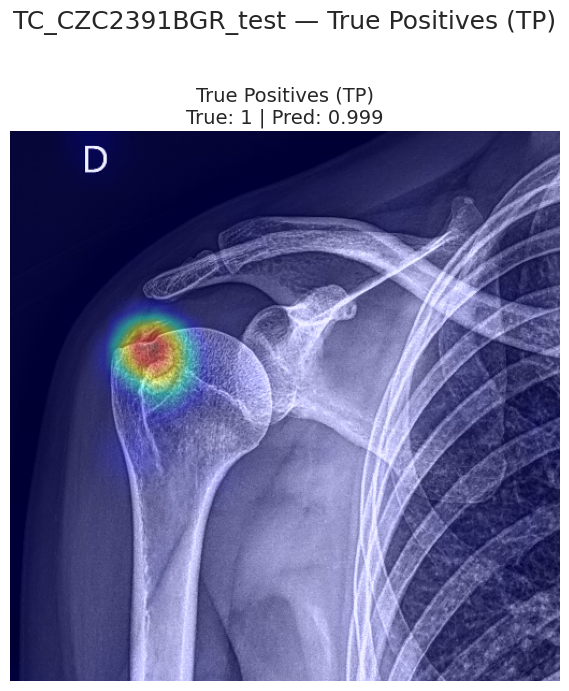

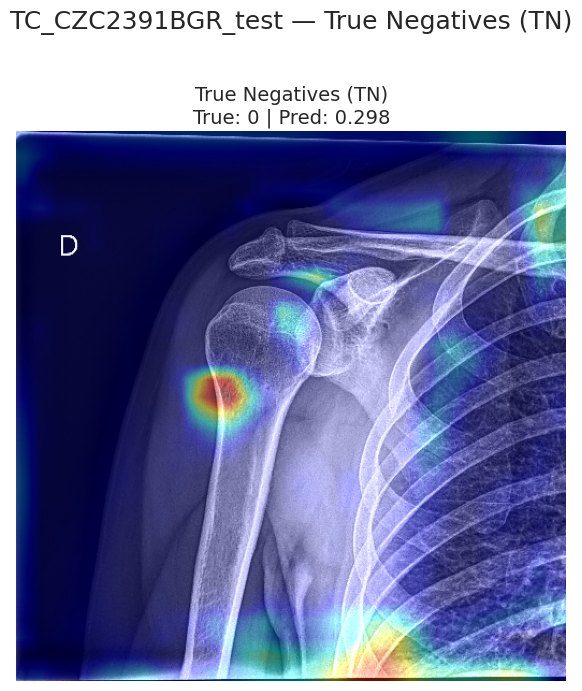

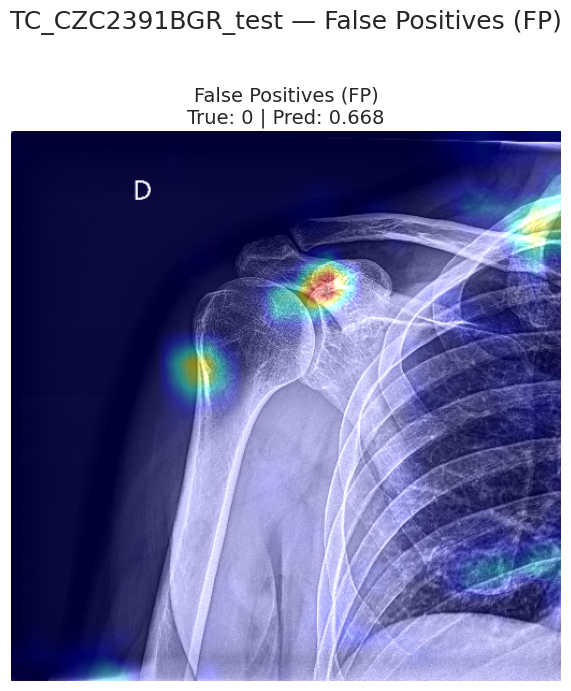

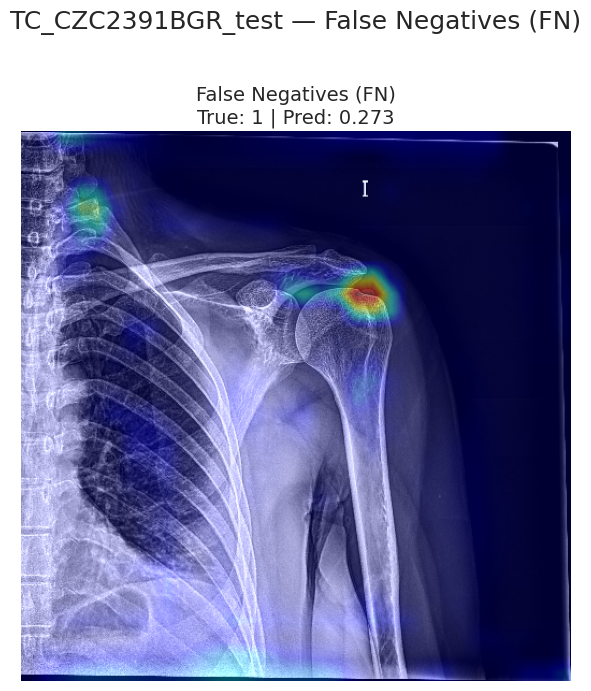


Showing representative examples for subset: TC_CZC2161RCP_test


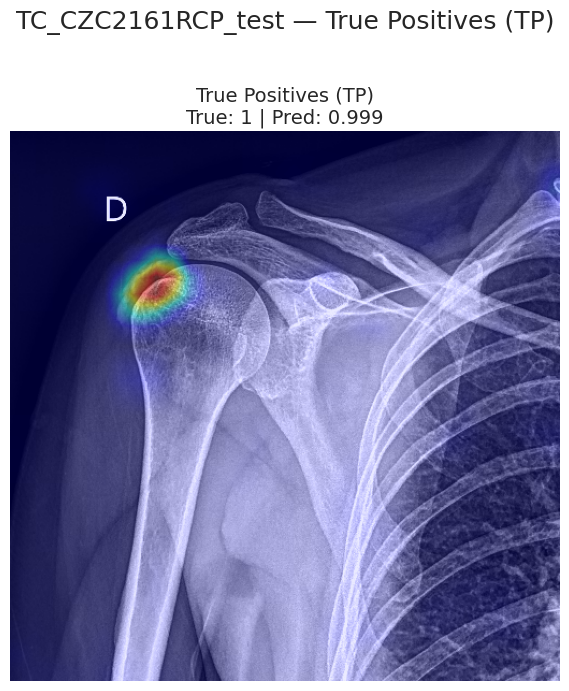

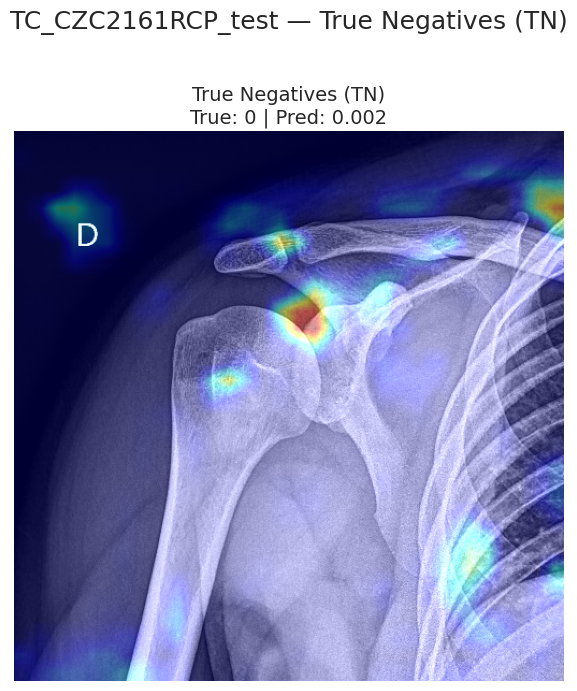

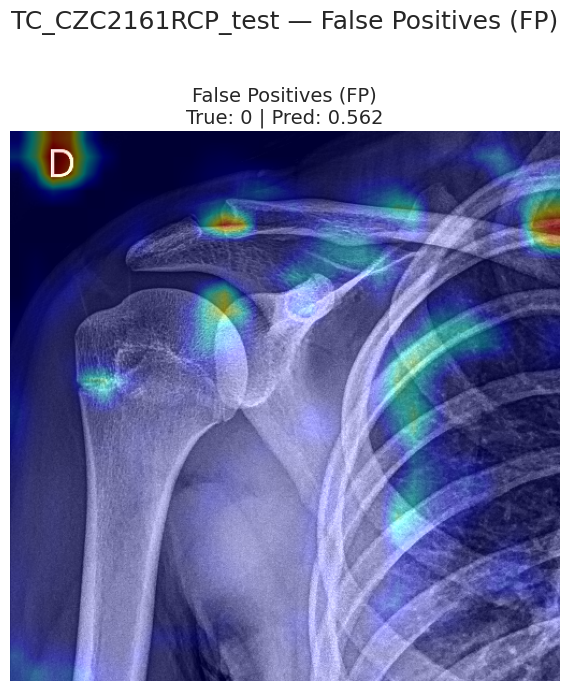

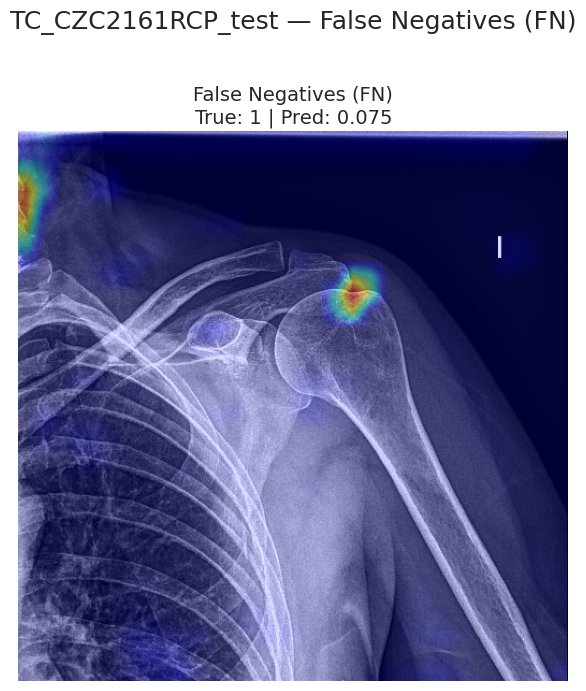


Showing representative examples for subset: TC_PRIMO_test


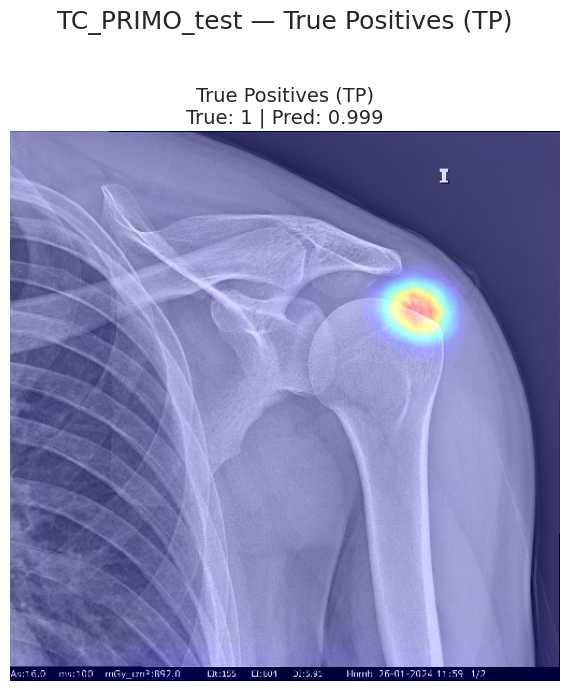

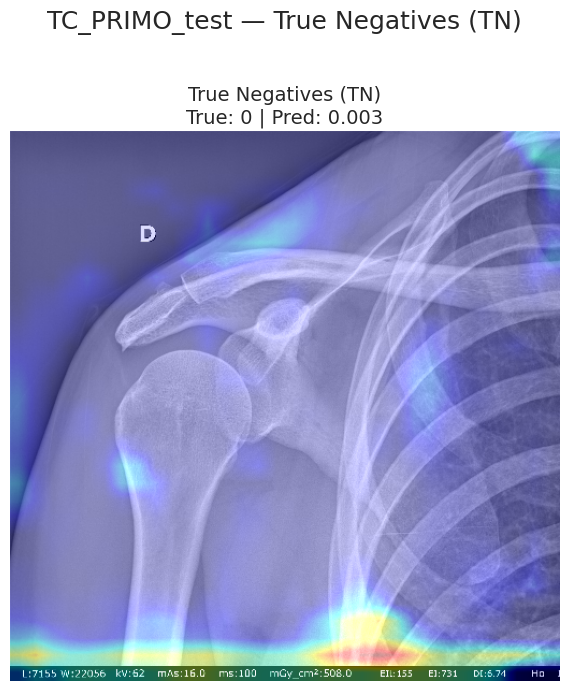

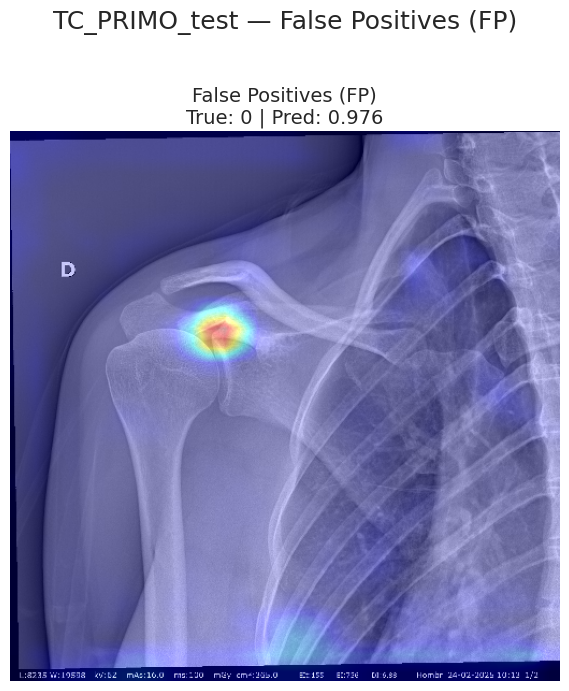

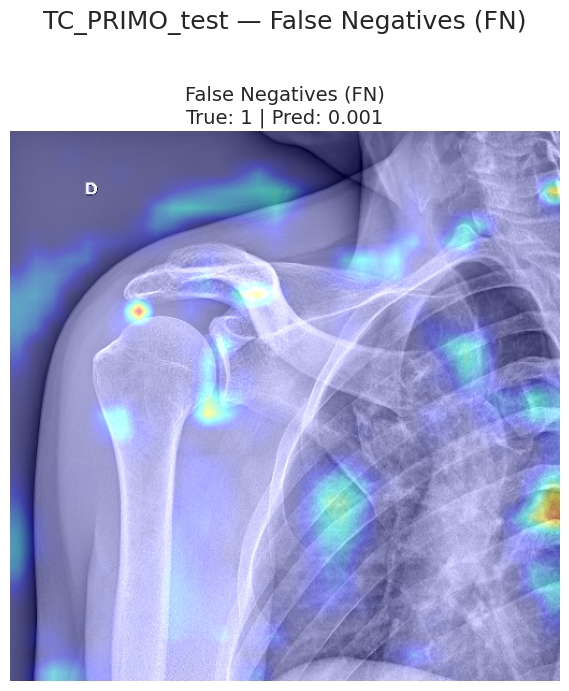

Grad-CAM visualization completed.


In [26]:
# Display representative Grad-CAM heatmaps

plot_representative_heatmaps(
    heatmaps_dict,
    y_true_dict,
    y_pred_dict,
    max_examples=1,
    threshold=0.5  
)

print("Grad-CAM visualization completed.")


#### **6.2. Explainability of the ML model (SHAP value and permutation importance)**

Starting SHAP computation for 100 samples...


PermutationExplainer explainer: 101it [01:10,  1.32it/s]                         


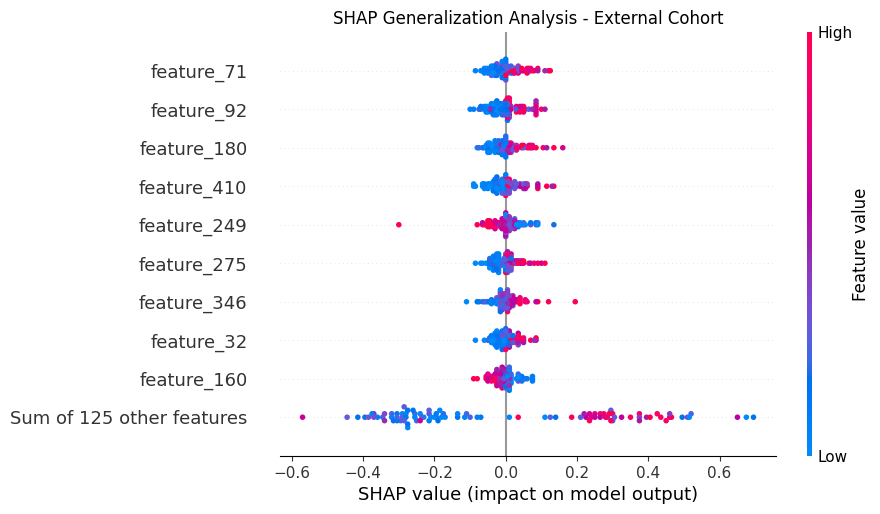

In [12]:
# 1. Load the model
best_estimator = joblib.load(modelo_path)

# 2. Prepare the external test set (134 features)
selected_features = best_estimator.feature_names_in_
X_test_sel = X_test[selected_features]

# 3. Reference background (Internal set substitute)
# We use a representative sample of the external set
background_data = X_test_sel.iloc[:100] 

# 4. Initialize Explainer
# Using the predict function makes it a black-box explainer
explainer = shap.Explainer(best_estimator.predict, background_data)

# 5. Compute SHAP values with explicit progress feedback
# This should trigger the tqdm bar automatically
print("Starting SHAP computation for 100 samples...")
shap_values = explainer(
    X_test_sel[:100], 
    max_evals=2 * len(selected_features) + 101,
    silent=False # Explicitly request progress output
)

# 6. Final Plot
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, max_display=10, show=False)
plt.title("SHAP Generalization Analysis - External Cohort")
plt.show()

Computing permutation importance for external generalization...

Top 10 features by permutation importance (External Cohort):
         feature  importance_mean  importance_std
69   feature_154         0.010390        0.006057
124  feature_124         0.009805        0.005753
126  feature_346         0.008831        0.006965
23   feature_275         0.008312        0.007521
2     feature_92         0.007792        0.007375
88   feature_152         0.006818        0.006818
1    feature_180         0.006753        0.006898
115    feature_4         0.006623        0.005353
5     feature_71         0.006234        0.008438
104  feature_425         0.006104        0.005221


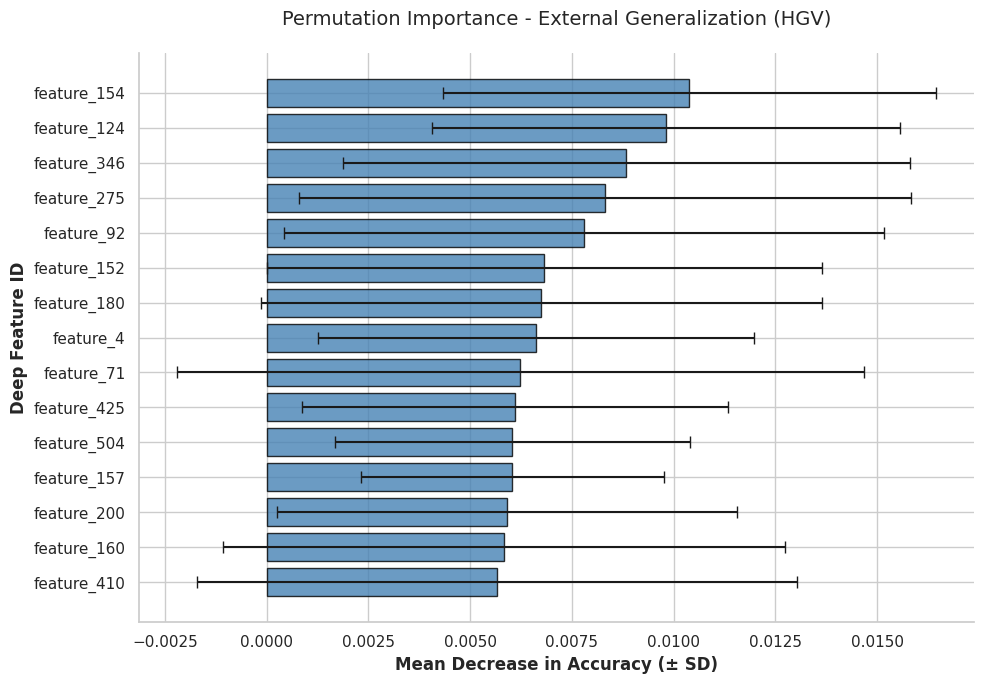

In [13]:
# Set plotting style for academic publication
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

# 1. Compute permutation importance on the EXTERNAL test set (HGV)
# This measures how much the model accuracy drops when a feature is shuffled
print("Computing permutation importance for external generalization...")
result_ext = permutation_importance(
    best_estimator,  # Your trained hybrid model
    X_test_sel,      # External features (134)
    y_test,          # External labels
    n_repeats=50,    # Number of shuffles for statistical robustness
    random_state=42, 
    n_jobs=-1        # Use all CPU cores
)

# 2. Organize results into a DataFrame for HGV
importance_df_ext = pd.DataFrame({
    'feature': X_test_sel.columns,
    'importance_mean': result_ext.importances_mean,
    'importance_std': result_ext.importances_std
}).sort_values(by='importance_mean', ascending=False)

# Log Top 10 for consistency check
print("\nTop 10 features by permutation importance (External Cohort):")
print(importance_df_ext.head(10))

# 3. Plotting the top-k features for the external set
top_k = 15
top_features_ext = importance_df_ext.head(top_k).copy()

plt.figure(figsize=(10, 7))

# Create horizontal bar plot with error bars (SD across 50 repeats)
plt.barh(
    top_features_ext['feature'][::-1], 
    top_features_ext['importance_mean'][::-1], 
    xerr=top_features_ext['importance_std'][::-1],
    color='#4682B4',  # SteelBlue professional color
    capsize=4,        
    edgecolor='black',
    alpha=0.8
)

# Labeling and formatting for the external cohort figure
plt.xlabel('Mean Decrease in Accuracy (± SD)', fontsize=12, fontweight='bold')
plt.ylabel('Deep Feature ID', fontsize=12, fontweight='bold')
plt.title('Permutation Importance - External Generalization (HGV)', fontsize=14, pad=20)

# Clean up visual layout
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()

# Save as Supplementary Material for the second institution
plt.savefig("Supplementary_Fig_Permutation_Importance_HGV.png", dpi=300, bbox_inches="tight")
plt.show()

### **7. Summary and Conclusions**

External validation at Institution 2 confirmed that the CNN maintains high diagnostic performance ($AUC \approx 0.94$) across different acquisition systems, proving its resilience to clinical and technical distribution shifts. The hybrid CNN–ML model achieved statistically comparable results, demonstrating that extracted deep features remain highly transferable.While Grad-CAM provided essential spatial validation by localizing calcifications, our SHAP and Permutation Importance analyses added a critical layer of evidence. We observed a remarkable consistency in the model's underlying logic: feature_92, feature_180, and feature_71 emerged as the top diagnostic drivers in both internal and external cohorts. This convergence—where the same features dictate both the impact (SHAP) and the accuracy (Permutation) across different hospitals—confirms that the system has captured universal radiomic signatures of the pathology. Consequently, the choice between the end-to-end CNN and the hybrid model can be based on practical needs—such as the CNN’s visual heatmaps or the hybrid model’s superior inference speed—with full confidence in their shared diagnostic robustness.